<a href="https://colab.research.google.com/github/visalakshijoga10/MasterThesisEmployeeAttritionIntention/blob/main/Employee_Attrition_Intention_Thesis_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A DATA-DRIVEN COMPARISON OF MACHINE LEARNING MODELS FOR PREDICTING EMPLOYEE ATTRITION INTENTION**

This notebook contains the full experiment for predicting employee attrition intention using six machine learning models: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, XGBoost and CatBoost. SHAP analysis is applied to the Random Forest model to explain the key factors influencing attrition intention.

1. Data Loading and Initial Inspection

The survey dataset is loaded from the CSV file. Column names are cleaned to remove extra spaces.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Data Preprocessing

Missing values are checked, age groups are created for visualisation, and the target variable AttritionIntention is converted to integer format.

In [2]:
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

In [3]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 25, 35, 45, 70],
    labels=["18-25", "26-35", "36-45", "46-70"],
    include_lowest=True
)

In [ ]:
print(data.shape)
print(data.head())
print(data.info())

(378, 25)
   Age  Gender  MaritalStatus  Education  EducationField  Department  JobRole  \
0   45       0              1          4               2           5        5   
1   27       1              0          2               2           1        1   
2   22       1              0          2               1           3        3   
3   29       0              0          2               2           1        1   
4   32       0              0          4               2           1        2   

   JobLevel  DailyWorkTravel  DistanceFromHome  ...  JobSatisfaction  \
0         5                4                 3  ...                5   
1         3                1                 2  ...                3   
2         2                5                 3  ...                3   
3         2                2                 1  ...                4   
4         3                2                 1  ...                4   

   TotalWorkExperience  YearsAtCompany  YearsInCurrentRole  \
0       

In [4]:
data = data.dropna().copy()
data["AttritionIntention"] = data["AttritionIntention"].astype(int)

In [5]:
print(data.dtypes)

print(data.shape)
print(data["AttritionIntention"].value_counts())

Age                                     int64
Gender                                  int64
MaritalStatus                           int64
Education                               int64
EducationField                          int64
Department                              int64
JobRole                                 int64
JobLevel                                int64
DailyWorkTravel                         int64
DistanceFromHome                        int64
OverTime                                int64
WorkLifeBalance                         int64
EnvironmentSatisfaction                 int64
JobInvolvement                          int64
ColleagueRelationshipSatisfaction       int64
JobSatisfaction                         int64
TotalWorkExperience                     int64
YearsAtCompany                          int64
YearsInCurrentRole                      int64
YearsSinceLastPromotion                 int64
TrainingProgramsLastYear                int64
MonthlyIncome                     

**3. Exploratory Data Analysis (EDA)**

Visual exploration of the dataset to understand the distribution of responses and identify key patterns related to attrition intention.

3.1 Attrition Intention Distribution

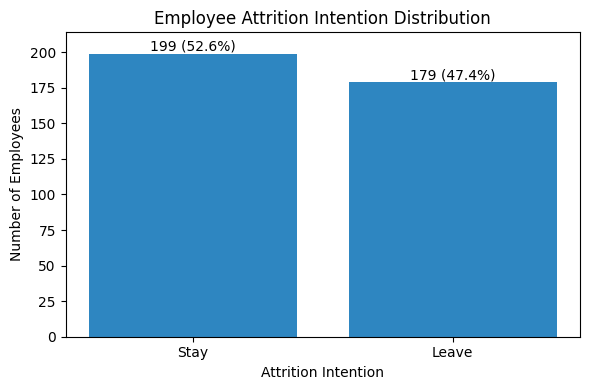

In [6]:
counts = data["AttritionIntention"].value_counts().sort_index()

plt.figure(figsize=(6,4))

bars = plt.bar(counts.index, counts.values, color="#2E86C1")

plt.title("Employee Attrition Intention Distribution", fontsize=12)
plt.xlabel("Attrition Intention")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["Stay", "Leave"])

total = counts.sum()

for bar in bars:
    yval = bar.get_height()
    percent = (yval / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             f"{int(yval)} ({percent:.1f}%)",
             ha="center", fontsize=10)

plt.ylim(0, max(counts.values) + 15)

plt.tight_layout()
plt.show()

3.2 Age Group vs Attrition Intention

In [7]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 25, 35, 45, 70],
    labels=["18-25", "26-35", "36-45", "46-70"]
)

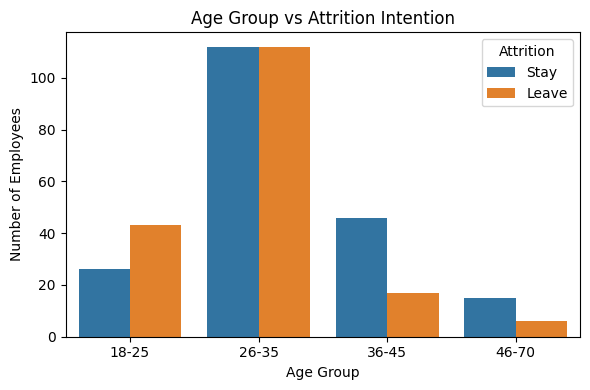

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="AgeGroup",
    hue="AttritionIntention",
    data=data
)

plt.title("Age Group vs Attrition Intention")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.3 Job Satisfaction vs Attrition Intention

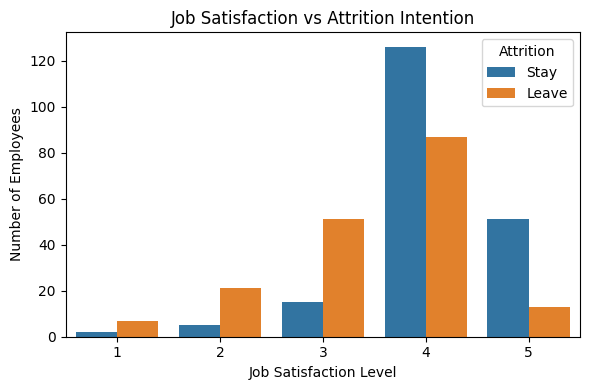

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction", hue="AttritionIntention", data=data)

plt.title("Job Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# Job Satisfaction vs Attrition
print("Job Satisfaction vs Attrition Intention:")
print(data.groupby("JobSatisfaction")[target_col].value_counts().unstack(fill_value=0))
print()
print(data.groupby("JobSatisfaction")[target_col].value_counts(normalize=True).unstack(fill_value=0).round(3) * 100)

Job Satisfaction vs Attrition Intention:
AttritionIntention    0   1
JobSatisfaction            
1                     2   7
2                     5  21
3                    15  51
4                   126  87
5                    51  13

AttritionIntention     0     1
JobSatisfaction               
1                   22.2  77.8
2                   19.2  80.8
3                   22.7  77.3
4                   59.2  40.8
5                   79.7  20.3


3.4 Environment Satisfaction vs Attrition Intention

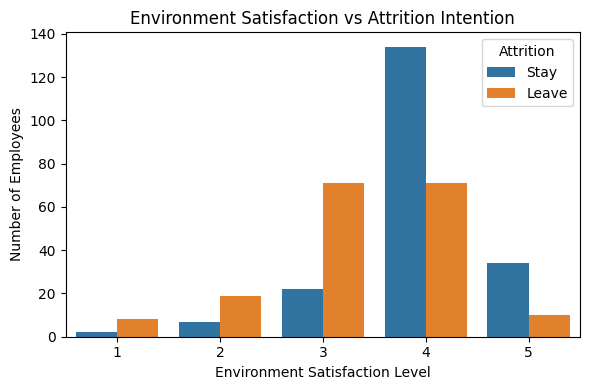

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="EnvironmentSatisfaction",
    hue="AttritionIntention",
    data=data
)

plt.title("Environment Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.5 Work-Life Balance vs Attrition Intention

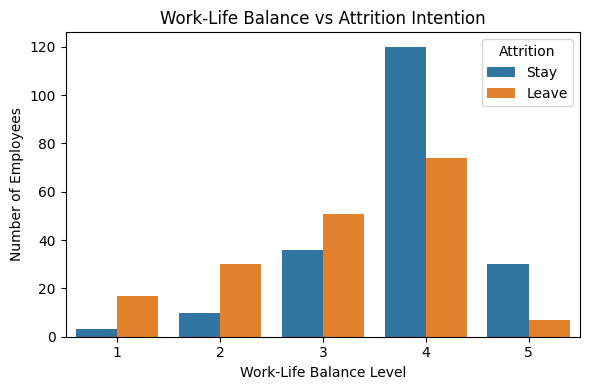

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="WorkLifeBalance",
    hue="AttritionIntention",
    data=data
)

plt.title("Work-Life Balance vs Attrition Intention", fontsize=12)
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.6 Overtime vs Attrition Intention

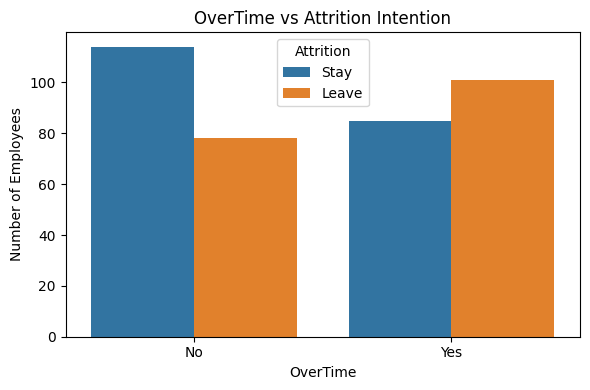

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OverTime",
    hue="AttritionIntention",
    data=data
)

plt.title("OverTime vs Attrition Intention", fontsize=12)
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["No", "Yes"])

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.7 Job Level vs Attrition Intention



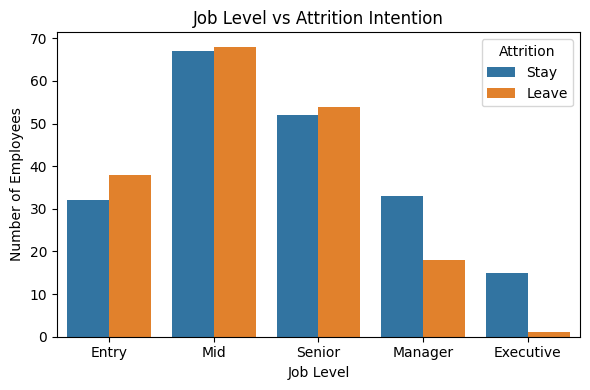

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

# Target column fix
data["AttritionIntention"] = data["AttritionIntention"].astype(int)

# Job level mapping
data["JobLevelLabel"] = data["JobLevel"].map({
    1: "Entry",
    2: "Mid",
    3: "Senior",
    4: "Manager",
    5: "Executive"
})

data = data.dropna(subset=["JobLevelLabel"])

plt.figure(figsize=(6,4))

sns.countplot(
    x="JobLevelLabel",
    hue="AttritionIntention",
    data=data,
    order=["Entry","Mid","Senior","Manager","Executive"]
)

plt.title("Job Level vs Attrition Intention", fontsize=12)
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.8 Marital Status vs Attrition Intention

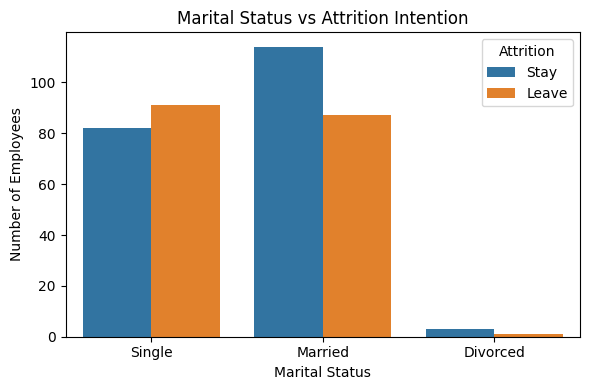

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="MaritalStatus",
    hue="AttritionIntention",
    data=data
)

plt.title("Marital Status vs Attrition Intention", fontsize=12)
plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.xticks([0, 1, 2], ["Single", "Married", "Divorced"])
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.9 Correlation Heatmap

Correlation between key satisfaction variables and attrition intention.

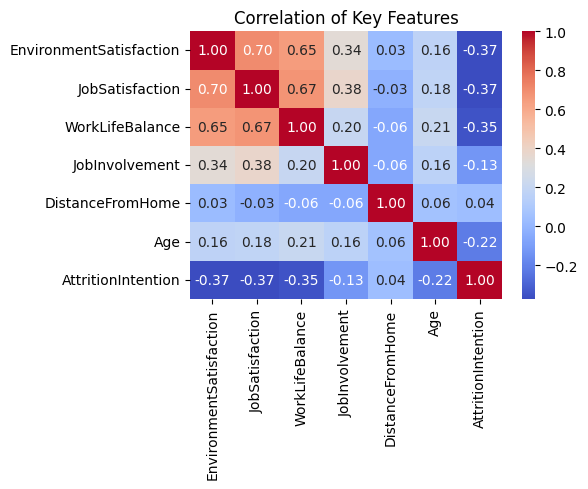

In [16]:
important_cols = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "DistanceFromHome",
    "Age",
    "AttritionIntention"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    data[important_cols].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation of Key Features")
plt.tight_layout()
plt.show()

In [17]:
corr = data[['EnvironmentSatisfaction', 'JobSatisfaction',
             'WorkLifeBalance', 'JobInvolvement',
             'DistanceFromHome', 'Age',
             'AttritionIntention']].corr()
print(corr['AttritionIntention'].round(2))

EnvironmentSatisfaction   -0.37
JobSatisfaction           -0.37
WorkLifeBalance           -0.35
JobInvolvement            -0.13
DistanceFromHome           0.04
Age                       -0.22
AttritionIntention         1.00
Name: AttritionIntention, dtype: float64


4. Machine Learning Model Training

The dataset is split into 80% training and 20% test sets using stratified sampling. Six machine learning models are trained and compared using 10-fold stratified cross-validation: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, XGBoost and CatBoost.

In [18]:
!pip install catboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data fresh
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

print("After cleaning:", data.shape)
print("\nClass distribution:")
print(data[target_col].value_counts())

# Features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Define 6 models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.1,
        random_seed=42,
        verbose=0,
        auto_class_weights="Balanced"
    )
}

print("\n6 models defined successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
After cleaning: (378, 24)

Class distribution:
AttritionIntention
0    199
1    179
Name: count, dtype: int64

Train shape: (302, 23)
Test shape: (76, 23)

6 models defined successfully.


4.1 10-Fold Stratified Cross-Validation Results

In [19]:
# =========================================================
# 10-FOLD CROSS VALIDATION ON TRAINING SET
# =========================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n========== 10-FOLD CROSS-VALIDATION RESULTS ==========")
for name, model in models.items():
    acc_scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="accuracy"
    )
    f1_scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="f1"
    )

    print(f"\n{name}")
    print("CV Accuracy:", np.round(acc_scores, 4))
    print("Mean CV Accuracy:", round(acc_scores.mean(), 4))
    print("Std Deviation:", round(acc_scores.std(), 4))
    print("Mean CV F1:", round(f1_scores.mean(), 4))


========== 10-FOLD CROSS-VALIDATION RESULTS ==========

Logistic Regression
CV Accuracy: [0.6774 0.5806 0.7    0.7    0.6667 0.5667 0.6    0.8    0.5333 0.7   ]
Mean CV Accuracy: 0.6525
Std Deviation: 0.0767
Mean CV F1: 0.615

Decision Tree
CV Accuracy: [0.6774 0.6774 0.5333 0.6667 0.5667 0.5    0.6333 0.7333 0.5    0.6333]
Mean CV Accuracy: 0.6122
Std Deviation: 0.0778
Mean CV F1: 0.5702

Random Forest
CV Accuracy: [0.6774 0.5806 0.7333 0.6333 0.7667 0.7667 0.7333 0.7667 0.5333 0.6667]
Mean CV Accuracy: 0.6858
Std Deviation: 0.0785
Mean CV F1: 0.6539

SVM
CV Accuracy: [0.7742 0.5161 0.6333 0.6333 0.5667 0.6    0.7    0.7333 0.7333 0.6333]
Mean CV Accuracy: 0.6524
Std Deviation: 0.0774
Mean CV F1: 0.6204

XGBoost
CV Accuracy: [0.6452 0.6452 0.6667 0.6333 0.7    0.6333 0.7    0.8    0.6    0.6333]
Mean CV Accuracy: 0.6657
Std Deviation: 0.0536
Mean CV F1: 0.6308

CatBoost
CV Accuracy: [0.7419 0.5806 0.7333 0.6    0.7333 0.7667 0.7667 0.7667 0.6333 0.6333]
Mean CV Accuracy: 0.6956
Std D

5. Model Evaluation

Each model is evaluated using Accuracy, Precision, Recall, and F1-Score on the held-out test set.

In [20]:
# =========================================================
# TEST SET EVALUATION
# =========================================================
from sklearn.metrics import precision_score, recall_score

print("\n========== TEST SET RESULTS ==========")
trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results)
print("\n========== SUMMARY TABLE ==========")
print(results_df.sort_values(
    by="Accuracy", ascending=False).to_string(index=False))


========== TEST SET RESULTS ==========

Logistic Regression
Accuracy: 0.6842
Precision: 0.6765
Recall: 0.6389
F1-score: 0.6571
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        40
           1       0.68      0.64      0.66        36

    accuracy                           0.68        76
   macro avg       0.68      0.68      0.68        76
weighted avg       0.68      0.68      0.68        76

Confusion Matrix:
[[29 11]
 [13 23]]

Decision Tree
Accuracy: 0.6316
Precision: 0.6429
Recall: 0.5
F1-score: 0.5625
              precision    recall  f1-score   support

           0       0.62      0.75      0.68        40
           1       0.64      0.50      0.56        36

    accuracy                           0.63        76
   macro avg       0.63      0.62      0.62        76
weighted avg       0.63      0.63      0.63        76

Confusion Matrix:
[[30 10]
 [18 18]]

Random Forest
Accuracy: 0.75
Precision: 0.7742
Recall: 0.6667
F1

5.1 Model Accuracy Comparison

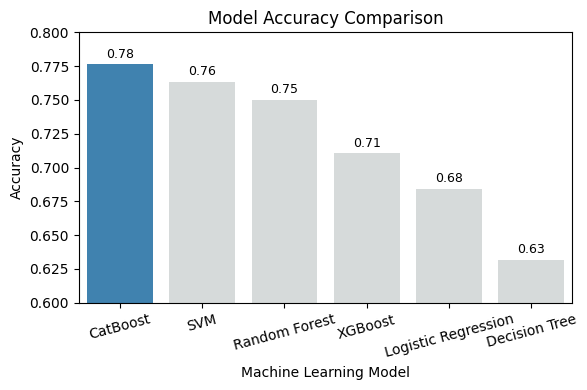

In [21]:
results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x="Model",
    y="Accuracy",
    hue="Model",          #  add this
    data=results_df,
    palette=['#2E86C1'] + ['#D5DBDB']*(len(results_df)-1),
    legend=False          #  remove duplicate legend
)

# Add values on bars
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=9)

plt.title("Model Accuracy Comparison", fontsize=12)
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0.6, 0.8)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

5.2 ROC Curve and AUC Analysis

ROC curves and AUC values for all six models to assess overall classification performance.

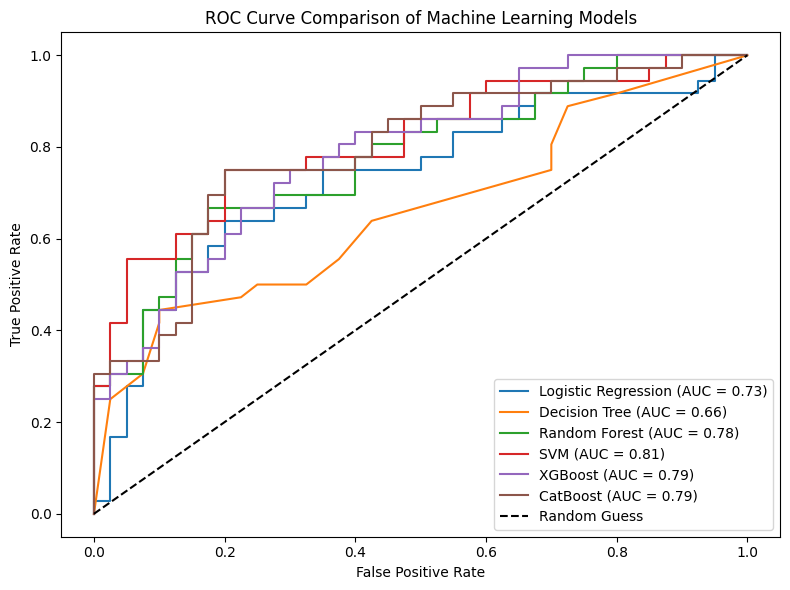

In [22]:
# =========================================================
# ROC CURVE ANALYSIS
# =========================================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    except:
        pass

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    auc_score = roc_auc_score(y_test, y_score)
    print(f"{name}: AUC = {round(auc_score, 2)}")

Logistic Regression: AUC = 0.73
Decision Tree: AUC = 0.66
Random Forest: AUC = 0.78
SVM: AUC = 0.81
XGBoost: AUC = 0.79
CatBoost: AUC = 0.79


**6. SHAP Analysis**

SHAP (SHapley Additive Explanations) is applied to the CatBoost model to explain which features most strongly influence employee attrition intention.

6.1 SHAP Beeswarm Summary Plot

Shape: (76, 23)


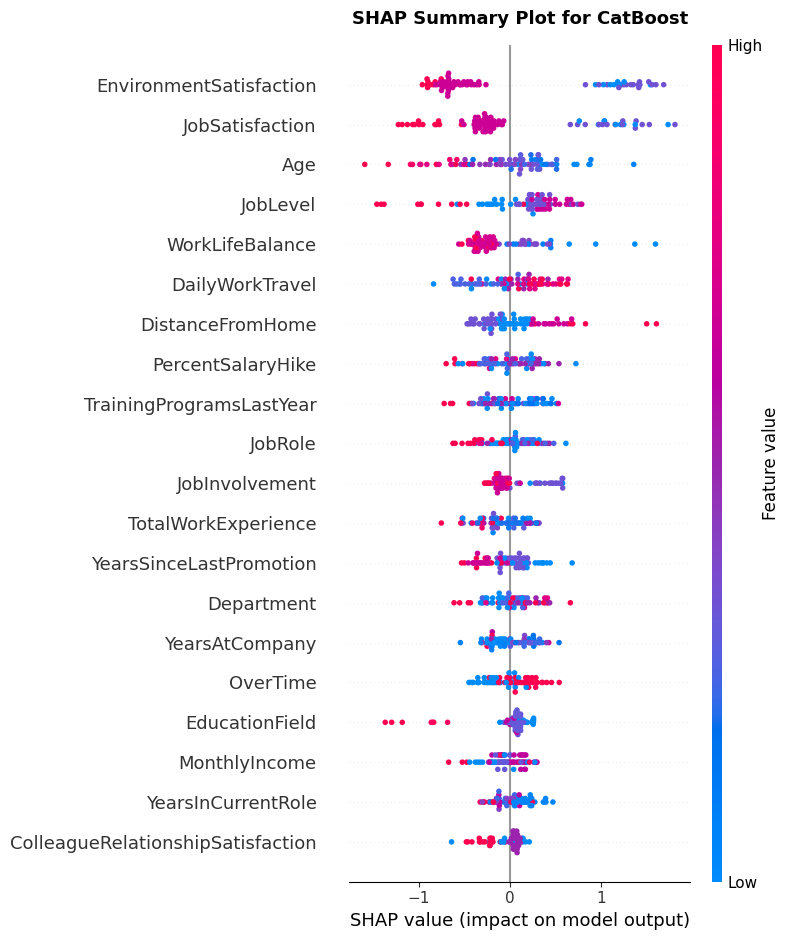

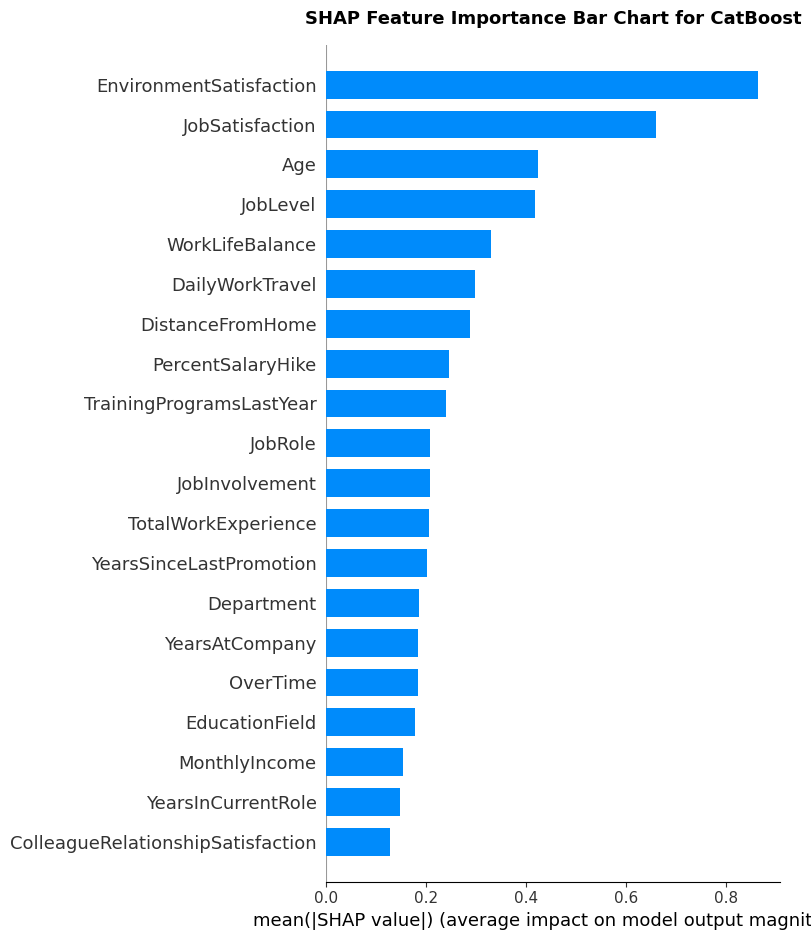


Top 10 Features by SHAP Importance (CatBoost):
                 Feature  SHAP_Importance
 EnvironmentSatisfaction         0.863795
         JobSatisfaction         0.658785
                     Age         0.424089
                JobLevel         0.416512
         WorkLifeBalance         0.328243
         DailyWorkTravel         0.297787
        DistanceFromHome         0.287645
       PercentSalaryHike         0.245033
TrainingProgramsLastYear         0.238596
                 JobRole         0.207516


In [24]:
# =========================================================
# SHAP ANALYSIS ON CATBOOST (Best Performing Model)
# =========================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

# Train CatBoost for SHAP
cb_shap = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cb_shap.fit(X_train, y_train)

# SHAP TreeExplainer on CatBoost
explainer = shap.TreeExplainer(cb_shap)
shap_values = explainer.shap_values(X_test)

# CatBoost returns 2D array directly for binary classification
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    shap_class1 = shap_values
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
else:
    shap_class1 = shap_values

print("Shape:", shap_class1.shape)

# ── Beeswarm Plot ─────────────────────────────────────
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X_test.columns),
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot for CatBoost",
          fontsize=13, fontweight="bold", loc="center", pad=15)
plt.tight_layout()
plt.show()

# ── Bar Chart ─────────────────────────────────────────
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X_test.columns),
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance Bar Chart for CatBoost",
          fontsize=13, fontweight="bold", loc="center", pad=15)
plt.tight_layout()
plt.show()

# ── Top 10 Features Table ─────────────────────────────
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": np.abs(shap_class1).mean(axis=0)
}).sort_values("SHAP_Importance", ascending=False).reset_index(drop=True)

print("\nTop 10 Features by SHAP Importance (CatBoost):")
print(shap_importance.head(10).to_string(index=False))

**7. Dataset Verification Repor**

This section verifies all dataset statistics reported in the thesis including total records, missing values, class distribution, demographic breakdowns and satisfaction means by attrition intention.

In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. LOAD DATA
# =========================================================
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# =========================================================
# 2. CLEAN TARGET
# =========================================================
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

print("="*60)
print("COMPLETE DATASET VERIFICATION REPORT")
print("="*60)

print(f"\nTotal Records: {len(data)}")
print(f"Total Variables: {len(data.columns)}")
print(f"Missing Values: {data.isnull().sum().sum()}")

print(f"\nTarget Variable Distribution:")
print(f"Stay (0): {data[target_col].value_counts()[0]} ({round(data[target_col].value_counts()[0]/len(data)*100,1)}%)")
print(f"Leave (1): {data[target_col].value_counts()[1]} ({round(data[target_col].value_counts()[1]/len(data)*100,1)}%)")

# =========================================================
# 3. HELPER FUNCTION
# =========================================================
def show_table(data, col, label_map, title):
    print(f"\n{'='*60}")
    print(f"TABLE: {title}")
    print(f"{'='*60}")
    temp = data.copy()
    temp["_label"] = temp[col].map(label_map)
    table = temp.groupby("_label")[target_col].value_counts().unstack(fill_value=0)
    table.columns = ["Stay", "Leave"]
    table["Total"] = table["Stay"] + table["Leave"]
    table["Stay %"] = round(table["Stay"] / table["Total"] * 100, 1)
    table["Leave %"] = round(table["Leave"] / table["Total"] * 100, 1)
    table["% of Total"] = round(table["Total"] / len(data) * 100, 1)
    print(table.to_string())

# =========================================================
# 4. GENDER TABLE
# =========================================================
show_table(data, "Gender",
    {0: "Male", 1: "Female"},
    "Gender vs Attrition Intention")

# =========================================================
# 5. MARITAL STATUS TABLE
# =========================================================
show_table(data, "MaritalStatus",
    {0: "Single", 1: "Married", 2: "Divorced"},
    "Marital Status vs Attrition Intention")

# =========================================================
# 6. EDUCATION TABLE
# =========================================================
show_table(data, "Education",
    {1: "Diploma", 2: "Bachelor", 3: "Master", 4: "PhD", 5: "Other"},
    "Education Level vs Attrition Intention")

# =========================================================
# 7. EDUCATION FIELD TABLE
# =========================================================
show_table(data, "EducationField",
    {1: "IT/CS", 2: "Engineering", 3: "Business", 4: "Medical", 5: "Other"},
    "Education Field vs Attrition Intention")

# =========================================================
# 8. DEPARTMENT TABLE
# =========================================================
show_table(data, "Department",
    {1: "Engineering", 2: "IT", 3: "Sales", 4: "R&D", 5: "Other"},
    "Department vs Attrition Intention")

# =========================================================
# 9. JOB LEVEL TABLE
# =========================================================
show_table(data, "JobLevel",
    {1: "Entry", 2: "Mid", 3: "Senior", 4: "Manager", 5: "Executive"},
    "Job Level vs Attrition Intention")

# =========================================================
# 10. JOB ROLE TABLE
# =========================================================
show_table(data, "JobRole",
    {1: "Technical/Engineering", 2: "Management",
     3: "Finance", 4: "HR", 5: "Other"},
    "Job Role vs Attrition Intention")

# =========================================================
# 11. OVERTIME TABLE
# =========================================================
show_table(data, "OverTime",
    {0: "No Overtime", 1: "Overtime"},
    "Overtime vs Attrition Intention")

# =========================================================
# 12. DAILY WORK TRAVEL TABLE
# =========================================================
show_table(data, "DailyWorkTravel",
    {1: "Never", 2: "Rarely", 3: "Occasionally",
     4: "Frequently", 5: "Very Frequently"},
    "Daily Work Travel vs Attrition Intention")

# =========================================================
# 13. DISTANCE FROM HOME TABLE
# =========================================================
show_table(data, "DistanceFromHome",
    {1: "0-5 km", 2: "6-15 km", 3: "16-30 km",
     4: "31-50 km", 5: "50+ km"},
    "Distance From Home vs Attrition Intention")

# =========================================================
# 14. MONTHLY INCOME TABLE
# =========================================================
show_table(data, "MonthlyIncome",
    {1: "Very Low", 2: "Low", 3: "Medium",
     4: "High", 5: "Very High"},
    "Monthly Income vs Attrition Intention")

# =========================================================
# 15. PERCENT SALARY HIKE TABLE
# =========================================================
show_table(data, "PercentSalaryHike",
    {1: "No Hike", 2: "1-5%", 3: "6-10%",
     4: "11-20%", 5: "Above 20%"},
    "Percent Salary Hike vs Attrition Intention")

# =========================================================
# 16. WORK LIFE BALANCE TABLE
# =========================================================
show_table(data, "WorkLifeBalance",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Work-Life Balance vs Attrition Intention")

# =========================================================
# 17. ENVIRONMENT SATISFACTION TABLE
# =========================================================
show_table(data, "EnvironmentSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Environment Satisfaction vs Attrition Intention")

# =========================================================
# 18. JOB SATISFACTION TABLE
# =========================================================
show_table(data, "JobSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Job Satisfaction vs Attrition Intention")

# =========================================================
# 19. JOB INVOLVEMENT TABLE
# =========================================================
show_table(data, "JobInvolvement",
    {1: "Not Involved", 2: "Low", 3: "Moderate",
     4: "High", 5: "Extremely Involved"},
    "Job Involvement vs Attrition Intention")

# =========================================================
# 20. COLLEAGUE RELATIONSHIP SATISFACTION TABLE
# =========================================================
show_table(data, "ColleagueRelationshipSatisfaction",
    {1: "Very Dissatisfied", 2: "Dissatisfied",
     3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"},
    "Colleague Relationship Satisfaction vs Attrition Intention")

# =========================================================
# 21. AGE GROUP TABLE
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Age Group vs Attrition Intention")
print(f"{'='*60}")
bins = [0, 25, 35, 45, 100]
labels = ["18-25", "26-35", "36-45", "46-70"]
data["AgeGroup"] = pd.cut(data["Age"], bins=bins, labels=labels)
age_table = data.groupby("AgeGroup")[target_col].value_counts().unstack(fill_value=0)
age_table.columns = ["Stay", "Leave"]
age_table["Total"] = age_table["Stay"] + age_table["Leave"]
age_table["Stay %"] = round(age_table["Stay"] / age_table["Total"] * 100, 1)
age_table["Leave %"] = round(age_table["Leave"] / age_table["Total"] * 100, 1)
age_table["% of Total"] = round(age_table["Total"] / len(data) * 100, 1)
print(age_table.to_string())

# =========================================================
# 22. NUMERICAL VARIABLES SUMMARY
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Numerical Variables Summary")
print(f"{'='*60}")
num_cols = ["Age", "TotalWorkExperience", "YearsAtCompany",
            "YearsInCurrentRole", "YearsSinceLastPromotion",
            "TrainingProgramsLastYear"]
available = [c for c in num_cols if c in data.columns]
print(data[available].describe().round(2).to_string())

# =========================================================
# 23. SATISFACTION MEANS BY ATTRITION
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Satisfaction Means by Attrition Intention")
print(f"{'='*60}")
sat_cols = ["EnvironmentSatisfaction", "JobSatisfaction",
            "WorkLifeBalance", "JobInvolvement",
            "ColleagueRelationshipSatisfaction"]
available = [c for c in sat_cols if c in data.columns]
means = data.groupby(target_col)[available].mean().round(2)
means.index = ["Stay", "Leave"]
print(means.to_string())

COMPLETE DATASET VERIFICATION REPORT

Total Records: 378
Total Variables: 24
Missing Values: 0

Target Variable Distribution:
Stay (0): 199 (52.6%)
Leave (1): 179 (47.4%)

TABLE: Gender vs Attrition Intention
        Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                 
Female    71     58    129    55.0     45.0        34.1
Male     128    121    249    51.4     48.6        65.9

TABLE: Marital Status vs Attrition Intention
          Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                   
Divorced     3      1      4    75.0     25.0         1.1
Married    114     87    201    56.7     43.3        53.2
Single      82     91    173    47.4     52.6        45.8

TABLE: Education Level vs Attrition Intention
          Stay  Leave  Total  Stay %  Leave %  % of Total
_label                                                   
Bachelor   107    116    223    48.0     52.0        59.0
Diploma   

**8. Correlation Verification**

This section verifies the correlation values between all variables and attrition intention as reported in the thesis correlation heatmap.

In [26]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. LOAD DATA
# =========================================================
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"

# =========================================================
# 2. CLEAN TARGET
# =========================================================
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

# =========================================================
# 3. CORRELATION TABLE ONLY
# =========================================================
print(f"\n{'='*60}")
print("TABLE: Correlation of All Variables with Attrition Intention")
print(f"{'='*60}")

numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()[target_col].drop(target_col).sort_values()
print(corr.round(4).to_string())

print(f"\n{'='*60}")
print("VERIFICATION COMPLETE")
print(f"{'='*60}")


TABLE: Correlation of All Variables with Attrition Intention
JobSatisfaction                     -0.3740
EnvironmentSatisfaction             -0.3716
WorkLifeBalance                     -0.3490
Age                                 -0.2209
ColleagueRelationshipSatisfaction   -0.2029
TotalWorkExperience                 -0.1986
JobLevel                            -0.1639
TrainingProgramsLastYear            -0.1593
JobInvolvement                      -0.1291
PercentSalaryHike                   -0.1211
YearsInCurrentRole                  -0.1197
YearsSinceLastPromotion             -0.1178
EducationField                      -0.1137
MaritalStatus                       -0.1020
MonthlyIncome                       -0.1005
YearsAtCompany                      -0.0995
Department                          -0.0581
JobRole                             -0.0467
Education                           -0.0360
Gender                              -0.0345
DistanceFromHome                     0.0391
DailyWorkTrave

**9. Dataset Summary Statistics Verification**

This section verifies the mean values and class distribution reported in Table 2 of the thesis.

In [27]:
import pandas as pd

data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

# Mean values
print("Mean Age:", round(data["Age"].mean(), 2))
print("Mean Work Experience:", round(data["TotalWorkExperience"].mean(), 2))
print("Mean Years at Company:", round(data["YearsAtCompany"].mean(), 2))

# Range values
print("\nAge Range:", data["Age"].min(), "-", data["Age"].max())
print("Work Experience Range:", data["TotalWorkExperience"].min(), "-", data["TotalWorkExperience"].max())
print("Years at Company Range:", data["YearsAtCompany"].min(), "-", data["YearsAtCompany"].max())

# Class distribution
print("\nClass Distribution:")
print(data["AttritionIntention"].value_counts())
print(data["AttritionIntention"].value_counts(normalize=True).round(3) * 100)

Mean Age: 31.97
Mean Work Experience: 8.26
Mean Years at Company: 4.05

Age Range: 18 - 69
Work Experience Range: 1 - 45
Years at Company Range: 1 - 37

Class Distribution:
AttritionIntention
0    199
1    179
Name: count, dtype: int64
AttritionIntention
0    52.6
1    47.4
Name: proportion, dtype: float64
